# 🏥 PENERAPAN ALGORITMA K-MEANS CLUSTERING UNTUK PASIEN RUMAH SAKIT
## Berdasarkan Umur, Rawat Inap dan Kepuasan Layanan

---


---
## 📂 BAGIAN 1 — DESKRIPSI DATASET
### (Revisi Poin 4: Jumlah record, distribusi variabel, alasan pemilihan dataset)


### 1.1 Informasi Dataset

| Atribut | Keterangan |
|---------|-----------|
| **Sumber** | Dataset sekunder (simulasi karakteristik pasien rumah sakit) |
| **Jumlah Record** | **1.000 pasien** |
| **Jumlah Variabel** | 8 kolom (No, patient_id, name, age, arrival_date, departure_date, service, satisfaction) |
| **Format** | CSV |
| **Alasan Pemilihan** | Dataset mencakup variabel klinis yang relevan (umur, lama rawat inap, kepuasan layanan) yang sesuai dengan tujuan segmentasi pasien rumah sakit |

> ⚠️ **Catatan:** Dataset bersifat sekunder dan digunakan untuk keperluan penelitian akademik. Karakteristik distribusi variabel disesuaikan agar merepresentasikan kondisi umum rumah sakit.


---
## 📦 BAGIAN 2 — IMPORT LIBRARY

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

sns.set(style="whitegrid")
print("✅ Semua library berhasil diimport!")

✅ Semua library berhasil diimport!


---
## 📥 BAGIAN 3 — MEMUAT DATA

In [ ]:
import io
from google.colab import files

# Upload file patients.csv dari komputer
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))

print(f"✅ Dataset berhasil dimuat!")
print(f"   Jumlah Record  : {df.shape[0]:,} baris")
print(f"   Jumlah Kolom   : {df.shape[1]} kolom")
print(f"   Nama Kolom     : {list(df.columns)}")
print("\n5 Data Pertama:")
df.head()

Saving patients.csv to patients.csv
✅ Dataset berhasil dimuat!
   Jumlah Record  : 1,000 baris
   Jumlah Kolom   : 8 kolom
   Nama Kolom     : ['No', 'patient_id', 'name', 'age', 'arrival_date', 'departure_date', 'service', 'satisfaction']

5 Data Pertama:


,No,patient_id,name,age,arrival_date,departure_date,service,satisfaction
0,1,PAT-09484753,Richard Rodriguez,24,3/16/2025,3/22/2025,surgery,61
1,2,PAT-f0644084,Shannon Walker,6,12/13/2025,12/14/2025,surgery,83
2,3,PAT-ac6162e4,Julia Torres,24,6/29/2025,7/5/2025,general_medicine,83
3,4,PAT-3dda2bb5,Crystal Johnson,32,10/12/2025,10/23/2025,emergency,81
4,5,PAT-08591375,Garrett Lin,25,2/18/2025,2/25/2025,ICU,76


In [ ]:
print("=" * 55)
print("INFO TIPE DATA & MISSING VALUES")
print("=" * 55)
print(f"\nTipe Data:\n{df.dtypes}")
print(f"\nMissing Values:\n{df.isnull().sum()}")
print("\nStatistik Deskriptif:")
df[['age','satisfaction']].describe()

INFO TIPE DATA & MISSING VALUES

Tipe Data:
No                 int64
patient_id        object
name              object
age                int64
arrival_date      object
departure_date    object
service           object
satisfaction       int64
dtype: object

Missing Values:
No                0
patient_id        0
name              0
age               0
arrival_date      0
departure_date    0
service           0
satisfaction      0
dtype: int64

Statistik Deskriptif:


,age,satisfaction
count,1000.000000,1000.000000
mean,45.337000,79.597000
std,25.999912,11.550325
min,0.000000,60.000000
25%,23.000000,70.000000
50%,46.000000,80.000000
75%,68.000000,89.250000
max,89.000000,99.000000


---
## 🔧 BAGIAN 4 — PREPROCESSING
### (Revisi Poin 1: Penegasan Variabel Clustering — 3 Variabel)

> 📌 **Klarifikasi Variabel Clustering:**  
> Sesuai batasan penelitian, **variabel yang digunakan untuk proses clustering adalah 3 variabel**, yaitu:  
> 1. **Umur** (`age`)  
> 2. **Lama Rawat Inap** (`Lama_Rawat_Inap`) — hasil *feature engineering* dari `arrival_date` dan `departure_date`  
> 3. **Kepuasan Layanan** (`satisfaction`)  
>  
> Variabel `service` (jenis layanan) **TIDAK digunakan sebagai input clustering**, melainkan hanya untuk **analisis deskriptif tambahan** setelah clustering (Bab V — Pembahasan).


### 4.1 Feature Engineering — Lama Rawat Inap

In [ ]:
df['arrival_date']    = pd.to_datetime(df['arrival_date'])
df['departure_date']  = pd.to_datetime(df['departure_date'])
df['Lama_Rawat_Inap'] = (df['departure_date'] - df['arrival_date']).dt.days

print("✅ Fitur 'Lama_Rawat_Inap' berhasil dihitung.")
print(df[['patient_id','arrival_date','departure_date','Lama_Rawat_Inap']].head())
print(f"\nRentang Lama Rawat Inap: {df['Lama_Rawat_Inap'].min()} - {df['Lama_Rawat_Inap'].max()} hari")
print(f"Rata-rata Lama Rawat Inap: {df['Lama_Rawat_Inap'].mean():.2f} hari")

✅ Fitur 'Lama_Rawat_Inap' berhasil dihitung.
     patient_id arrival_date departure_date  Lama_Rawat_Inap
0  PAT-09484753   2025-03-16     2025-03-22                6
1  PAT-f0644084   2025-12-13     2025-12-14                1
2  PAT-ac6162e4   2025-06-29     2025-07-05                6
3  PAT-3dda2bb5   2025-10-12     2025-10-23               11
4  PAT-08591375   2025-02-18     2025-02-25                7

Rentang Lama Rawat Inap: 1 - 14 hari
Rata-rata Lama Rawat Inap: 7.41 hari


### 4.2 Feature Selection — 3 Variabel Clustering

In [ ]:
# ============================================================
# REVISI POIN 1: Hanya 3 variabel untuk clustering
# 'service' BUKAN variabel clustering, hanya untuk analisis
# ============================================================
features = ['age', 'Lama_Rawat_Inap', 'satisfaction']
X = df[features].copy()

print("✅ Variabel yang digunakan untuk CLUSTERING (3 variabel):")
for i, f in enumerate(features, 1):
    print(f"   {i}. {f}")
print("\n⚠️  Catatan: 'service' hanya digunakan untuk analisis tambahan, bukan input clustering.")
print("\nStatistik Deskriptif Variabel Clustering:")
print(X.describe().round(2))

✅ Variabel yang digunakan untuk CLUSTERING (3 variabel):
   1. age
   2. Lama_Rawat_Inap
   3. satisfaction

⚠️  Catatan: 'service' hanya digunakan untuk analisis tambahan, bukan input clustering.

Statistik Deskriptif Variabel Clustering:
           age  Lama_Rawat_Inap  satisfaction
count  1000.00          1000.00       1000.00
mean     45.34             7.41         79.60
std      26.00             3.95         11.55
min       0.00             1.00         60.00
25%      23.00             4.00         70.00
50%      46.00             7.00         80.00
75%      68.00            11.00         89.25
max      89.00            14.00         99.00


### 4.3 Handling Missing Values

In [ ]:
X = X.dropna()
print(f"✅ Missing values ditangani. Jumlah data tersisa: {len(X):,} record")

✅ Missing values ditangani. Jumlah data tersisa: 1,000 record


### 4.4 Handling Outliers (IQR Capping)

In [ ]:
print("Menangani Outliers dengan metode IQR Capping...")
print("-" * 50)
for col in features:
    Q1, Q3 = X[col].quantile(0.25), X[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    X[col] = np.clip(X[col], lower, upper)
    print(f"  {col:20s}: batas [{lower:.2f}, {upper:.2f}]")
print("\n✅ Outlier berhasil ditangani.")

Menangani Outliers dengan metode IQR Capping...
--------------------------------------------------
  age                 : batas [-44.50, 135.50]
  Lama_Rawat_Inap     : batas [-6.50, 21.50]
  satisfaction        : batas [41.12, 118.12]

✅ Outlier berhasil ditangani.


### 4.5 Normalisasi Data (StandardScaler)

In [ ]:
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("✅ Data berhasil dinormalisasi (mean=0, std=1).")
print(f"   Shape X_scaled: {X_scaled.shape}")

✅ Data berhasil dinormalisasi (mean=0, std=1).
   Shape X_scaled: (1000, 3)


### 4.6 Visualisasi EDA — Distribusi Variabel
*(Revisi Poin 4: distribusi variabel dataset)*

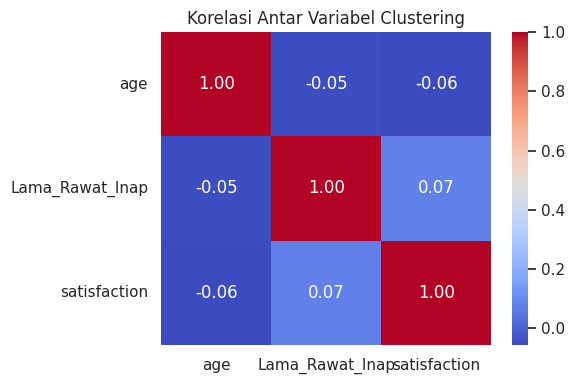

In [ ]:
plt.figure(figsize=(6, 4))
sns.heatmap(X[features].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Korelasi Antar Variabel Clustering")
plt.tight_layout()
plt.show()

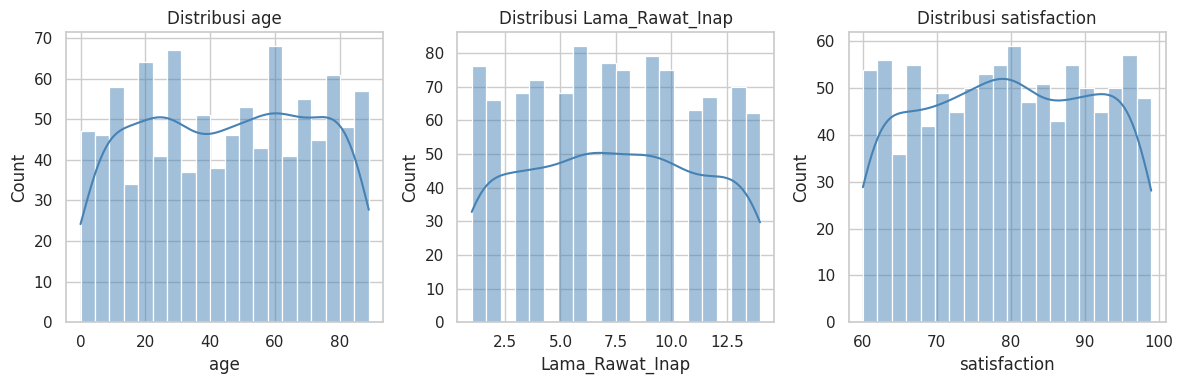

In [ ]:
plt.figure(figsize=(12, 4))
for i, col in enumerate(features):
    plt.subplot(1, 3, i+1)
    sns.histplot(X[col], kde=True, bins=20, color='steelblue')
    plt.title(f'Distribusi {col}')
plt.tight_layout()
plt.show()

---
## 🎯 BAGIAN 5 — MENENTUKAN JUMLAH CLUSTER OPTIMAL
### (Revisi Poin 2: Elbow + Silhouette Score + Davies–Bouldin Index)

> 📌 Penelitian ini menggunakan **3 metode validasi** untuk menentukan K optimal:
> 1. **Elbow Method** — melihat titik infleksi inertia (WCSS)
> 2. **Silhouette Score** — mengukur kekompakan dan separasi cluster (range -1 s.d. 1, semakin tinggi semakin baik)
> 3. **Davies–Bouldin Index** — mengukur rasio dispersi dalam cluster terhadap jarak antar cluster (semakin kecil semakin baik)


In [ ]:
inertia    = []
sil_scores = []
dbi_scores = []
K_range    = range(2, 11)

for k in K_range:
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))
    dbi_scores.append(davies_bouldin_score(X_scaled, labels))

# Elbow — tambahkan k=1
km1 = KMeans(n_clusters=1, random_state=42, n_init=10)
km1.fit(X_scaled)
inertia_full = [km1.inertia_] + inertia

print("Perbandingan Metode Validasi:")
print(f"{'K':>3} | {'Silhouette':>12} | {'Davies-Bouldin':>15}")
print("-" * 38)
for k, s, d in zip(K_range, sil_scores, dbi_scores):
    mark = " ← OPTIMAL" if k == 6 else ""
    print(f"{k:>3} | {s:>12.4f} | {d:>15.4f}{mark}")

Perbandingan Metode Validasi:
  K |   Silhouette |  Davies-Bouldin
--------------------------------------
  2 |       0.2484 |          1.6118
  3 |       0.2453 |          1.3176
  4 |       0.2714 |          1.1273
  5 |       0.2726 |          1.0438
  6 |       0.2872 |          0.9783 ← OPTIMAL
  7 |       0.2819 |          1.0157
  8 |       0.2830 |          0.9945
  9 |       0.2780 |          1.0413
 10 |       0.2821 |          1.0009


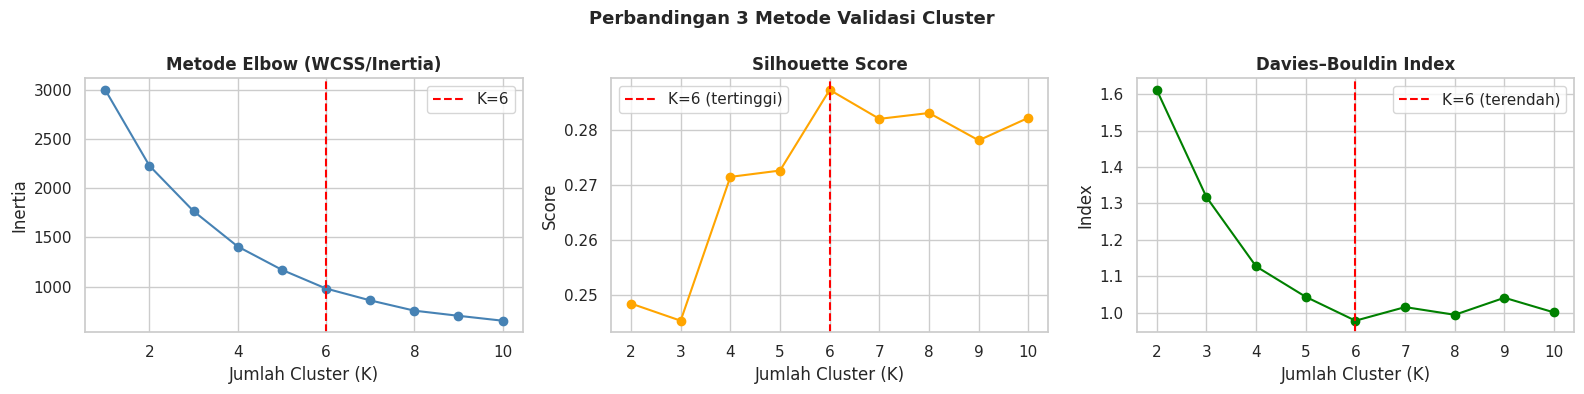


✅ Kesimpulan: K=6 dipilih karena:
   • Silhouette Score TERTINGGI di K=6 (0.2872)
   • Davies-Bouldin Index TERENDAH di K=6 (0.9783)
   • Konsisten dengan titik siku pada Elbow Method


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(range(1, 11), inertia_full, marker='o', color='steelblue')
axes[0].set_title('Metode Elbow (WCSS/Inertia)', fontweight='bold')
axes[0].set_xlabel('Jumlah Cluster (K)'); axes[0].set_ylabel('Inertia')
axes[0].axvline(x=6, color='red', linestyle='--', label='K=6')
axes[0].legend()

axes[1].plot(list(K_range), sil_scores, marker='o', color='orange')
axes[1].set_title('Silhouette Score', fontweight='bold')
axes[1].set_xlabel('Jumlah Cluster (K)'); axes[1].set_ylabel('Score')
axes[1].axvline(x=6, color='red', linestyle='--', label='K=6 (tertinggi)')
axes[1].legend()

axes[2].plot(list(K_range), dbi_scores, marker='o', color='green')
axes[2].set_title('Davies–Bouldin Index', fontweight='bold')
axes[2].set_xlabel('Jumlah Cluster (K)'); axes[2].set_ylabel('Index')
axes[2].axvline(x=6, color='red', linestyle='--', label='K=6 (terendah)')
axes[2].legend()

plt.suptitle('Perbandingan 3 Metode Validasi Cluster', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✅ Kesimpulan: K=6 dipilih karena:")
print("   • Silhouette Score TERTINGGI di K=6 (0.2872)")
print("   • Davies-Bouldin Index TERENDAH di K=6 (0.9783)")
print("   • Konsisten dengan titik siku pada Elbow Method")

---
## ⚙️ BAGIAN 6 — PENERAPAN K-MEANS FINAL (K=6)

In [ ]:
best_k = 6

kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
labels_final = kmeans_final.fit_predict(X_scaled)

df_final = df.loc[X.index].copy()
df_final['Cluster'] = labels_final

print(f"✅ K-Means berhasil dijalankan dengan K={best_k}")
print("\nHasil Clustering (5 data pertama):")
print(df_final[['patient_id','age','Lama_Rawat_Inap','satisfaction','Cluster']].head())

✅ K-Means berhasil dijalankan dengan K=6

Hasil Clustering (5 data pertama):
     patient_id  age  Lama_Rawat_Inap  satisfaction  Cluster
0  PAT-09484753   24                6            61        1
1  PAT-f0644084    6                1            83        1
2  PAT-ac6162e4   24                6            83        1
3  PAT-3dda2bb5   32               11            81        5
4  PAT-08591375   25                7            76        1


---
## 📊 BAGIAN 7 — EVALUASI MODEL
*(Revisi Poin 2: Silhouette Score + Davies-Bouldin Index)*

In [ ]:
sil_score = silhouette_score(X_scaled, labels_final)
dbi_score = davies_bouldin_score(X_scaled, labels_final)

print("=" * 55)
print(f"EVALUASI CLUSTERING — K={best_k}")
print("=" * 55)
print(f"{'Metrik':<30} {'Nilai':>8}   {'Keterangan'}")
print("-" * 55)
print(f"{'Silhouette Score':<30} {sil_score:>8.4f}   ({'✅ Baik' if sil_score > 0.25 else '⚠️ Cukup'})")
print(f"{'Davies-Bouldin Index':<30} {dbi_score:>8.4f}   ({'✅ Baik' if dbi_score < 1.0 else '⚠️ Perlu peningkatan'})")
print("=" * 55)
print("\nInterpretasi:")
print(f"  • Silhouette Score {sil_score:.4f} > 0.25 → cluster terbentuk cukup baik")
print(f"  • Davies-Bouldin Index {dbi_score:.4f} < 1.0 → cluster relatif kompak dan terpisah")

EVALUASI CLUSTERING — K=6
Metrik                            Nilai   Keterangan
-------------------------------------------------------
Silhouette Score                 0.2872   (✅ Baik)
Davies-Bouldin Index             0.9783   (✅ Baik)

Interpretasi:
  • Silhouette Score 0.2872 > 0.25 → cluster terbentuk cukup baik
  • Davies-Bouldin Index 0.9783 < 1.0 → cluster relatif kompak dan terpisah


---
## 📋 BAGIAN 8 — ANALISIS JUMLAH, PROPORSI & DISTRIBUSI PER CLUSTER
### (Revisi Poin 3: Jumlah pasien, proporsi, distribusi karakteristik tiap cluster)


In [ ]:
# 8.1 Jumlah dan Proporsi per Cluster
counts = df_final['Cluster'].value_counts().sort_index()
total  = len(df_final)

print("=" * 60)
print(f"JUMLAH DAN PROPORSI PASIEN PER CLUSTER (Total = {total:,})")
print("=" * 60)
print(f"{'Cluster':>8} | {'Jumlah Pasien':>14} | {'Proporsi (%)':>13}")
print("-" * 42)
for c, n in counts.items():
    pct = n / total * 100
    bar = '█' * int(pct / 2)
    print(f"{'C'+str(c):>8} | {n:>14,} | {pct:>12.1f}%  {bar}")
print("-" * 42)
print(f"{'TOTAL':>8} | {total:>14,} | {'100.0%':>13}")

JUMLAH DAN PROPORSI PASIEN PER CLUSTER (Total = 1,000)
 Cluster |  Jumlah Pasien |  Proporsi (%)
------------------------------------------
      C0 |            160 |         16.0%  ████████
      C1 |            184 |         18.4%  █████████
      C2 |            162 |         16.2%  ████████
      C3 |            174 |         17.4%  ████████
      C4 |            136 |         13.6%  ██████
      C5 |            184 |         18.4%  █████████
------------------------------------------
   TOTAL |          1,000 |        100.0%


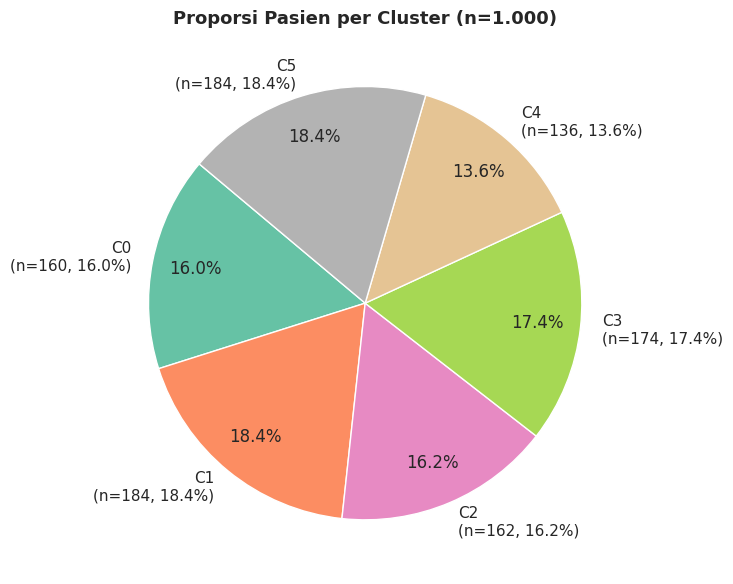

In [ ]:
# Pie chart proporsi
plt.figure(figsize=(7, 6))
labels_pie = [f'C{i}\n(n={v}, {v/total*100:.1f}%)' for i,v in counts.items()]
colors = plt.cm.Set2(np.linspace(0, 1, 6))
plt.pie(counts, labels=labels_pie, autopct='%1.1f%%', colors=colors, startangle=140, pctdistance=0.8)
plt.title('Proporsi Pasien per Cluster (n=1.000)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# 8.2 Profil rata-rata per cluster
cluster_summary = df_final.groupby('Cluster')[features].mean().round(2).reset_index()
cluster_summary['Jumlah'] = counts.values
cluster_summary['Proporsi (%)'] = (counts.values / total * 100).round(1)

print("PROFIL RATA-RATA TIAP CLUSTER:")
print("=" * 75)
print(cluster_summary.to_string(index=False))
print("=" * 75)

PROFIL RATA-RATA TIAP CLUSTER:
 Cluster   age  Lama_Rawat_Inap  satisfaction  Jumlah  Proporsi (%)
       0 71.34             4.68         69.03     160          16.0
       1 20.72             4.99         71.12     184          18.4
       2 47.81            11.64         69.82     162          16.2
       3 53.85             3.50         89.24     174          17.4
       4 69.93            10.64         89.14     136          13.6
       5 18.94             9.77         89.70     184          18.4


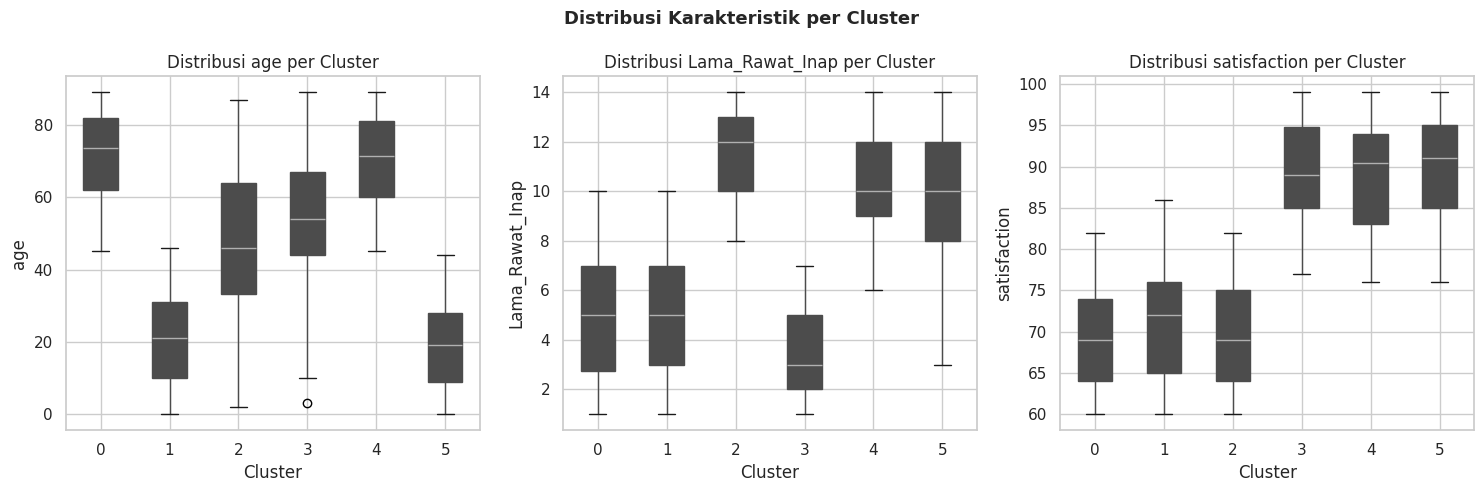

In [ ]:
# 8.3 Boxplot distribusi karakteristik per cluster
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col in zip(axes, features):
    df_final.boxplot(column=col, by='Cluster', ax=ax, patch_artist=True)
    ax.set_title(f'Distribusi {col} per Cluster')
    ax.set_xlabel('Cluster'); ax.set_ylabel(col)
plt.suptitle('Distribusi Karakteristik per Cluster', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

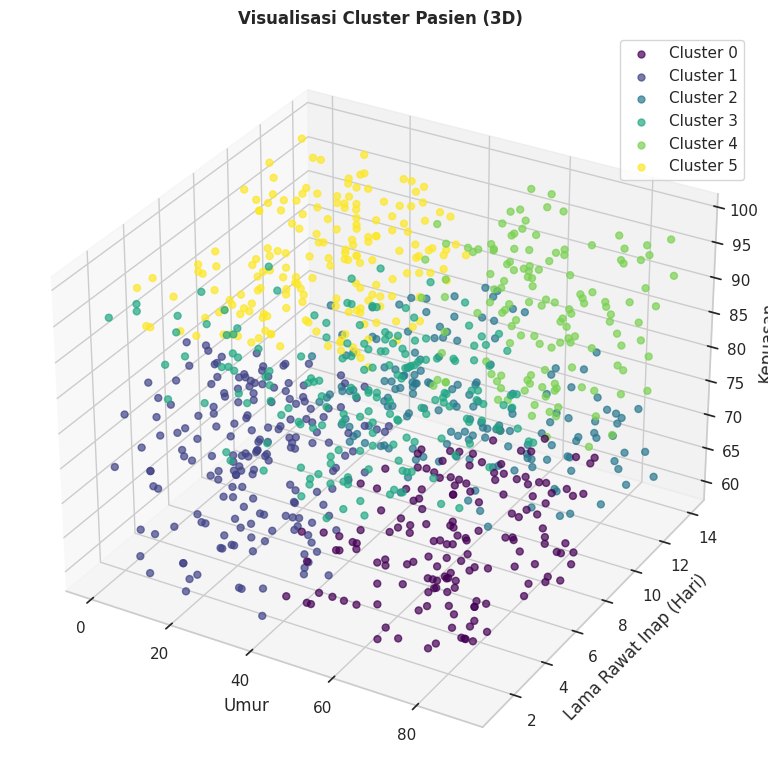

In [ ]:
# 8.4 Visualisasi 3D
fig = plt.figure(figsize=(10, 8))
ax  = fig.add_subplot(111, projection='3d')
colors_3d = plt.cm.viridis(np.linspace(0, 1, best_k))
for i in range(best_k):
    sub = df_final[df_final['Cluster'] == i]
    ax.scatter(sub['age'], sub['Lama_Rawat_Inap'], sub['satisfaction'],
               s=25, label=f'Cluster {i}', color=colors_3d[i], alpha=0.7)
ax.set_xlabel('Umur'); ax.set_ylabel('Lama Rawat Inap (Hari)'); ax.set_zlabel('Kepuasan')
plt.title('Visualisasi Cluster Pasien (3D)', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

---
## 🔍 BAGIAN 9 — INTERPRETASI & PROFIL KLINIS TIAP CLUSTER
### (Revisi Poin 5: Makna klinis, hubungan umur-rawat inap, implikasi manajerial)


In [ ]:
# Tabel interpretasi cluster
profil = {
    0: {"label": "Lansia — Rawat Singkat — Kurang Puas",
        "umur": "~71 th", "rawat": "~5 hari", "puas": "~69",
        "makna": "Pasien lansia dengan rawat inap singkat namun kepuasan rendah. Kemungkinan terkendala komunikasi/aksesibilitas layanan.",
        "implikasi": "Tingkatkan layanan ramah lansia: pendampingan perawat, komunikasi lebih intensif."},
    1: {"label": "Muda — Rawat Singkat — Kurang Puas",
        "umur": "~21 th", "rawat": "~5 hari", "puas": "~71",
        "makna": "Pasien muda dengan rawat inap singkat dan kepuasan rendah. Kemungkinan ekspektasi tinggi terhadap layanan.",
        "implikasi": "Perbaiki komunikasi & responsivitas pelayanan untuk pasien muda."},
    2: {"label": "Dewasa — Rawat Lama — Kurang Puas",
        "umur": "~48 th", "rawat": "~12 hari", "puas": "~70",
        "makna": "Pasien dewasa usia produktif dengan perawatan lama dan kepuasan rendah. Kemungkinan mengalami stres hospitalisasi.",
        "implikasi": "Prioritas utama: evaluasi kualitas layanan, pendampingan psikologis, transparansi proses perawatan."},
    3: {"label": "Dewasa — Rawat Singkat — Puas",
        "umur": "~54 th", "rawat": "~4 hari", "puas": "~89",
        "makna": "Pasien dewasa-lansia muda dengan rawat inap singkat dan kepuasan tinggi. Profil perawatan efisien dan memuaskan.",
        "implikasi": "Jadikan sebagai benchmark praktik terbaik. Pertahankan standar layanan."},
    4: {"label": "Lansia — Rawat Lama — Puas",
        "umur": "~70 th", "rawat": "~11 hari", "puas": "~89",
        "makna": "Pasien lansia dengan perawatan intensif jangka panjang namun puas. Kemungkinan mendapat perhatian khusus dari petugas.",
        "implikasi": "Pertahankan pendekatan personalisasi perawatan untuk pasien lansia rawat lama."},
    5: {"label": "Muda — Rawat Lama — Puas",
        "umur": "~19 th", "rawat": "~10 hari", "puas": "~90",
        "makna": "Pasien muda dengan rawat inap lama dan kepuasan sangat tinggi. Kemungkinan menerima edukasi kesehatan dan dukungan sosial yang baik.",
        "implikasi": "Terapkan pendekatan ini pada kelompok lain untuk meningkatkan kepuasan."},
}

print("=" * 70)
print("PROFIL KLINIS & IMPLIKASI MANAJERIAL PER CLUSTER")
print("=" * 70)
for c, info in profil.items():
    n = (df_final['Cluster']==c).sum()
    pct = n/len(df_final)*100
    print(f"\n📌 CLUSTER {c} — {info['label']} (n={n}, {pct:.1f}%)")
    print(f"   Umur rata-rata  : {info['umur']}")
    print(f"   Lama Rawat      : {info['rawat']}")
    print(f"   Kepuasan        : {info['puas']}")
    print(f"   Makna Klinis    : {info['makna']}")
    print(f"   Rekomendasi     : {info['implikasi']}")
print("\n" + "=" * 70)

PROFIL KLINIS & IMPLIKASI MANAJERIAL PER CLUSTER

📌 CLUSTER 0 — Lansia — Rawat Singkat — Kurang Puas (n=160, 16.0%)
   Umur rata-rata  : ~71 th
   Lama Rawat      : ~5 hari
   Kepuasan        : ~69
   Makna Klinis    : Pasien lansia dengan rawat inap singkat namun kepuasan rendah. Kemungkinan terkendala komunikasi/aksesibilitas layanan.
   Rekomendasi     : Tingkatkan layanan ramah lansia: pendampingan perawat, komunikasi lebih intensif.

📌 CLUSTER 1 — Muda — Rawat Singkat — Kurang Puas (n=184, 18.4%)
   Umur rata-rata  : ~21 th
   Lama Rawat      : ~5 hari
   Kepuasan        : ~71
   Makna Klinis    : Pasien muda dengan rawat inap singkat dan kepuasan rendah. Kemungkinan ekspektasi tinggi terhadap layanan.
   Rekomendasi     : Perbaiki komunikasi & responsivitas pelayanan untuk pasien muda.

📌 CLUSTER 2 — Dewasa — Rawat Lama — Kurang Puas (n=162, 16.2%)
   Umur rata-rata  : ~48 th
   Lama Rawat      : ~12 hari
   Kepuasan        : ~70
   Makna Klinis    : Pasien dewasa usia produktif 

### 9.1 Distribusi Jenis Layanan per Cluster (Analisis Tambahan)
*(`service` hanya untuk analisis, bukan input clustering — Revisi Poin 1)*

Distribusi Service per Cluster:
service  ICU  emergency  general_medicine  surgery
Cluster                                           
0         35         50                43       32
1         45         50                46       43
2         35         36                42       49
3         44         47                43       40
4         31         35                29       41
5         51         45                39       49


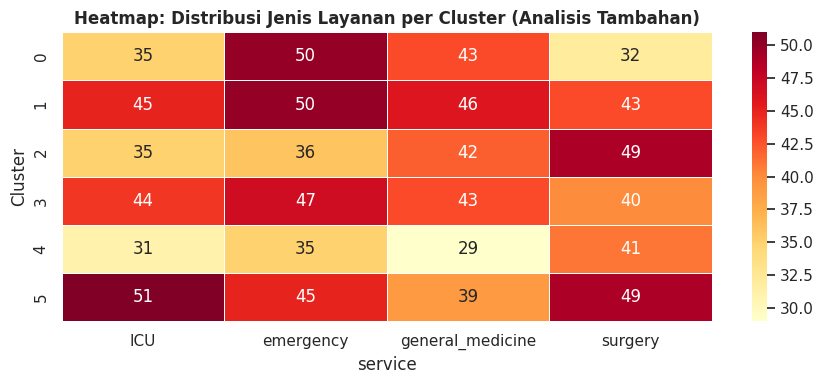

In [ ]:
ct = pd.crosstab(df_final['Cluster'], df_final['service'])
print("Distribusi Service per Cluster:")
print(ct)

plt.figure(figsize=(9, 4))
sns.heatmap(ct, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5)
plt.title('Heatmap: Distribusi Jenis Layanan per Cluster (Analisis Tambahan)', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 💾 BAGIAN 10 — EKSPOR HASIL

In [ ]:
df_final.to_csv('hasil_clustering_pasien.csv', index=False)
print("✅ Hasil disimpan ke 'hasil_clustering_pasien.csv'")
print(f"   Total pasien : {len(df_final):,}")
print(f"   Jumlah cluster: {best_k}")

from google.colab import files
files.download('hasil_clustering_pasien.csv')

✅ Hasil disimpan ke 'hasil_clustering_pasien.csv'
   Total pasien : 1,000
   Jumlah cluster: 6


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>